# Skin Lesion Boundary Detection Using Canny Edge Detection

Dataset: [HAM10000 (Skin Cancer MNIST)](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)

## 1. Setup

In [1]:
!pip -q install kagglehub

In [2]:
import os, glob, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_W, IMG_H = 512, 384
THRESHOLDS = [(50, 100), (100, 200), (150, 250)]

## 2. Dataset

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
meta_path = glob.glob(os.path.join(dataset_path, "**", "HAM10000_metadata.csv"), recursive=True)[0]

image_paths = {}
for f in glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True):
    image_paths[os.path.splitext(os.path.basename(f))[0]] = f

meta = pd.read_csv(meta_path)
meta["path"] = meta["image_id"].map(image_paths)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)
meta["dx"].value_counts()

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


## Task 1 — Load the Image

In [4]:
selection = pd.concat([
    meta[meta["dx"] == "nv"].sample(2, random_state=SEED),
    meta[meta["dx"] == "mel"].sample(2, random_state=SEED),
    meta[meta["dx"] == "bkl"].sample(1, random_state=SEED),
]).reset_index(drop=True)

names = [f"Image {i + 1}" for i in range(len(selection))]
originals = []
for p in selection["path"]:
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    originals.append(cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA))

selection[["image_id", "dx"]].assign(name=names)

,image_id,dx,name
0,ISIC_0025438,nv,Image 1
1,ISIC_0029881,nv,Image 2
2,ISIC_0028847,mel,Image 3
3,ISIC_0027102,mel,Image 4
4,ISIC_0028750,bkl,Image 5


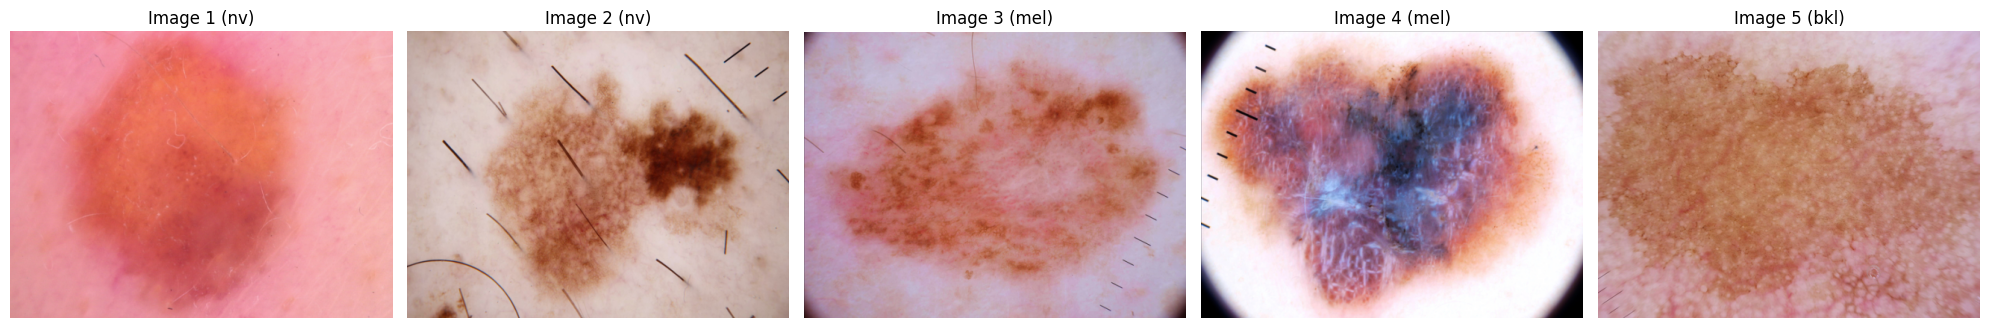

In [5]:
fig, axes = plt.subplots(1, len(originals), figsize=(4 * len(originals), 3.4))
for ax, img, n, dx in zip(axes, originals, names, selection["dx"]):
    ax.imshow(img)
    ax.set_title(f"{n} ({dx})")
    ax.axis("off")
plt.tight_layout()
plt.savefig("task1_original_images.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 2 — Preprocess the Image

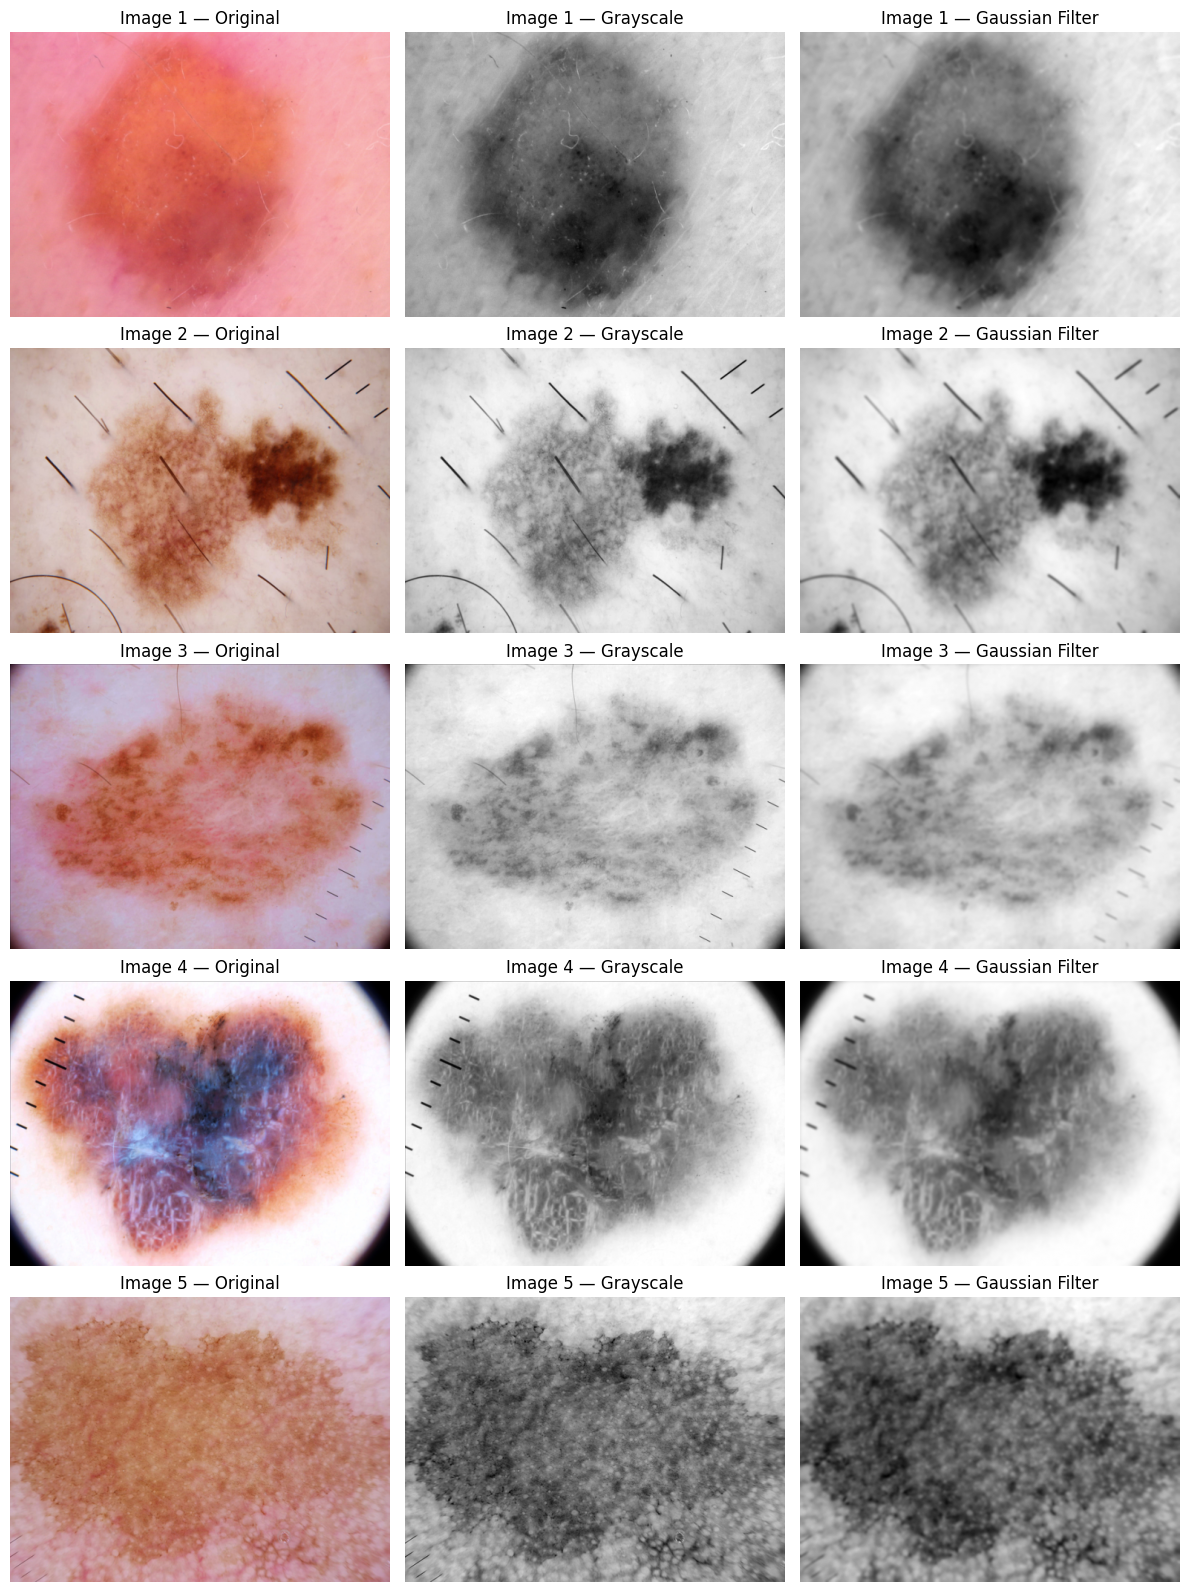

In [6]:
grays = [cv2.cvtColor(i, cv2.COLOR_RGB2GRAY) for i in originals]
gaussians = [cv2.GaussianBlur(g, (7, 7), 1.5) for g in grays]

fig, axes = plt.subplots(len(originals), 3, figsize=(12, 3.2 * len(originals)))
for r in range(len(originals)):
    for c, (im, t, cm) in enumerate([(originals[r], "Original", None), (grays[r], "Grayscale", "gray"), (gaussians[r], "Gaussian Filter", "gray")]):
        axes[r, c].imshow(im, cmap=cm)
        axes[r, c].set_title(f"{names[r]} — {t}")
        axes[r, c].axis("off")
plt.tight_layout()
plt.savefig("task2_preprocessing.png", dpi=130, bbox_inches="tight")
plt.show()

## Task 3 — Canny Edge Detection with Three Thresholds

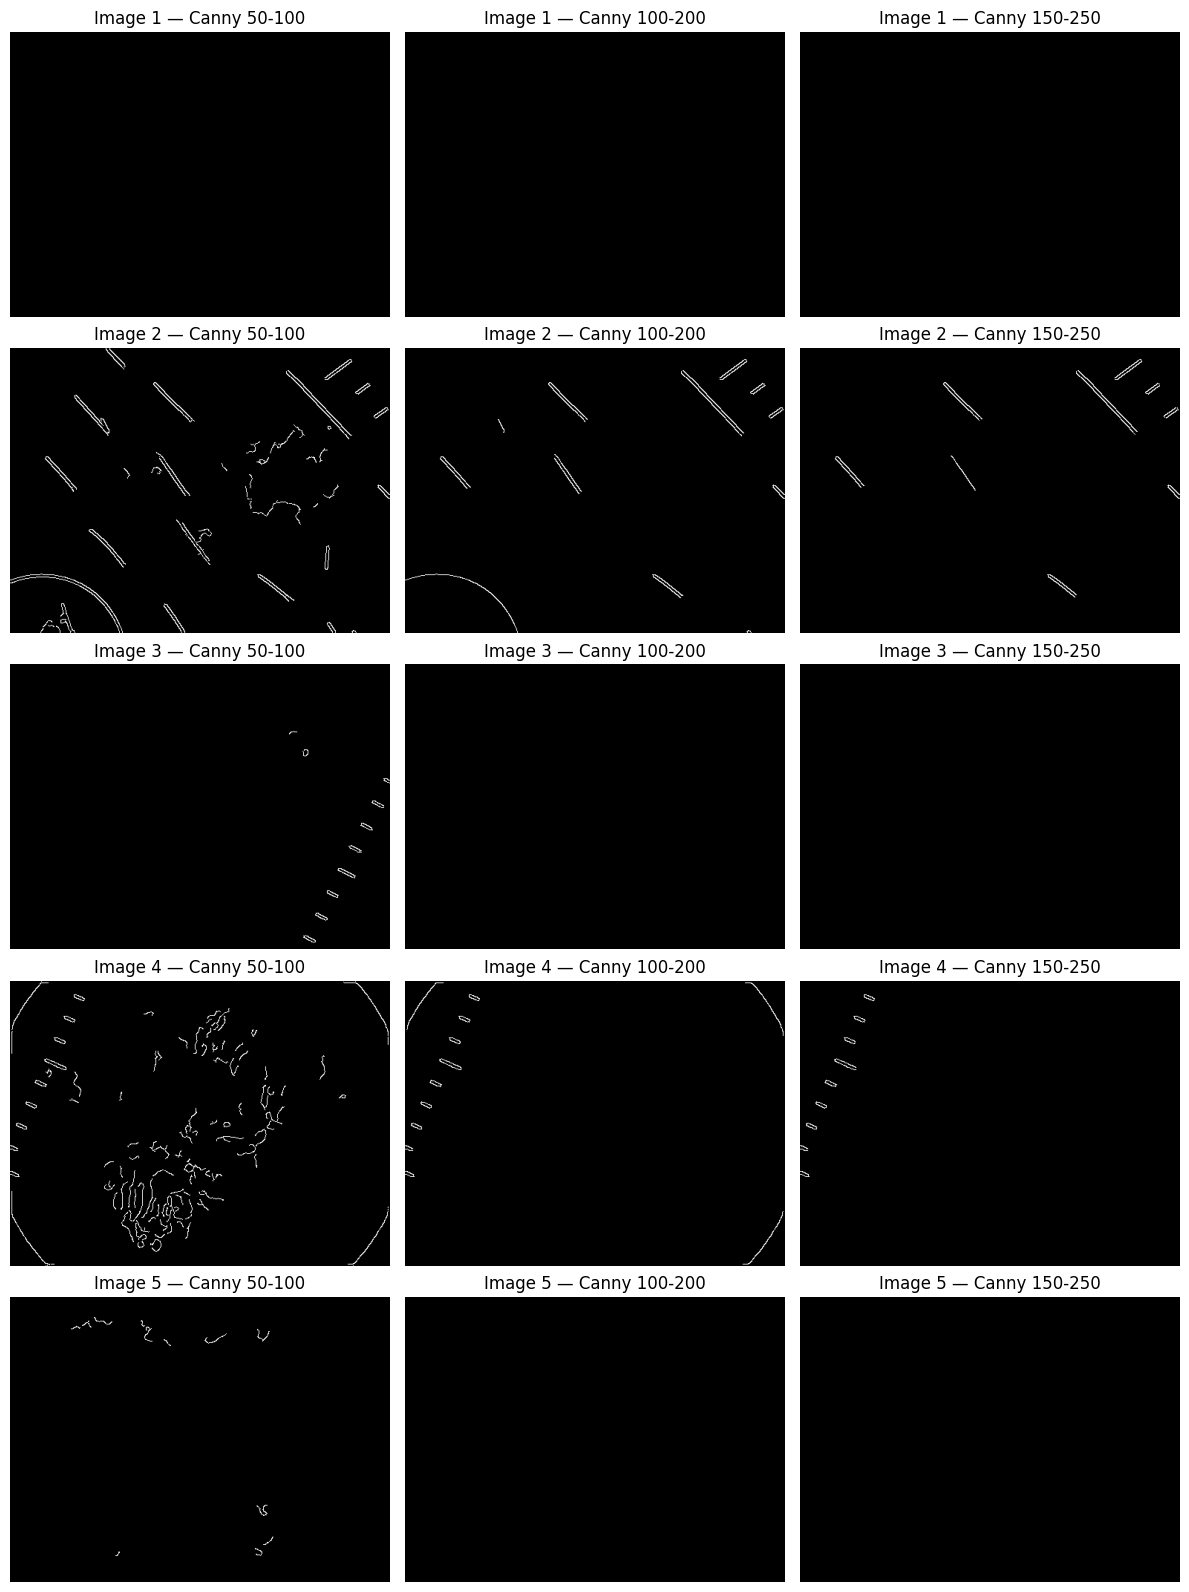

In [7]:
canny_maps = [[cv2.Canny(g, lo, hi) for lo, hi in THRESHOLDS] for g in gaussians]

fig, axes = plt.subplots(len(originals), 3, figsize=(12, 3.2 * len(originals)))
for r in range(len(originals)):
    for c, (lo, hi) in enumerate(THRESHOLDS):
        axes[r, c].imshow(canny_maps[r][c], cmap="gray")
        axes[r, c].set_title(f"{names[r]} — Canny {lo}-{hi}")
        axes[r, c].axis("off")
plt.tight_layout()
plt.savefig("task3_canny_thresholds.png", dpi=130, bbox_inches="tight")
plt.show()

## Boundary Extraction and Evaluation Utilities

In [8]:
def close_edges(edges, ksize=7, iters=2):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k, iterations=iters)


def extract_boundary(edges):
    h, w = edges.shape
    closed = close_edges(edges)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    valid = [c for c in contours if 200 < cv2.contourArea(c) < 0.9 * h * w]
    mask = np.zeros((h, w), np.uint8)
    if not valid:
        return mask, None
    best = max(valid, key=cv2.contourArea)
    cv2.drawContours(mask, [best], -1, 255, -1)
    return mask, best


def reference_mask(gray):
    blur = cv2.GaussianBlur(gray, (11, 11), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m)
    if n <= 1:
        return m
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return ndi.binary_fill_holes(labels == largest).astype(np.uint8) * 255


def dice(a, b):
    a, b = a > 0, b > 0
    s = a.sum() + b.sum()
    return 2 * (a & b).sum() / s if s else 0.0


def boundary_of(mask):
    er = cv2.erode(mask, np.ones((3, 3), np.uint8))
    return cv2.subtract(mask, er)


def edge_f1(edges, ref, tol=4):
    ref_b = boundary_of(ref) > 0
    if edges.sum() == 0 or ref_b.sum() == 0:
        return 0.0
    d_ref = ndi.distance_transform_edt(~ref_b)
    d_edge = ndi.distance_transform_edt(edges == 0)
    precision = (d_ref[edges > 0] <= tol).mean()
    recall = (d_edge[ref_b] <= tol).mean()
    return 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)


def noise_ratio(edges, min_size=30):
    n, labels, stats, _ = cv2.connectedComponentsWithStats((edges > 0).astype(np.uint8), connectivity=8)
    total = (edges > 0).sum()
    if total == 0:
        return 1.0
    small = stats[1:, cv2.CC_STAT_AREA]
    return small[small < min_size].sum() / total


refs = [reference_mask(g) for g in grays]

## Task 4 — Select the Best Result

In [9]:
rows = []
for r in range(len(originals)):
    for c, (lo, hi) in enumerate(THRESHOLDS):
        e = canny_maps[r][c]
        mask, cnt = extract_boundary(e)
        rows.append({
            "Image": names[r],
            "Threshold": f"{lo}-{hi}",
            "Edge Pixels": int((e > 0).sum()),
            "Edge F1": round(edge_f1(e, refs[r]), 3),
            "Dice": round(dice(mask, refs[r]), 3),
            "Noise Ratio": round(noise_ratio(e), 3),
        })

task4 = pd.DataFrame(rows)
task4_summary = task4.groupby("Threshold")[["Edge Pixels", "Edge F1", "Dice", "Noise Ratio"]].mean().round(3)
task4_summary["Score"] = (task4_summary["Edge F1"] + task4_summary["Dice"] + (1 - task4_summary["Noise Ratio"])) / 3
task4_summary = task4_summary.round(3).loc[[f"{lo}-{hi}" for lo, hi in THRESHOLDS]]
task4_summary

,Edge Pixels,Edge F1,Dice,Noise Ratio,Score
Threshold,,,,,
50-100,1561.2,0.080,0.027,0.419,0.229
100-200,459.4,0.007,0.000,0.612,0.132
150-250,314.4,0.008,0.000,0.615,0.131


Selected threshold: 50-100
50-100: edge pixels 1561, edge F1 0.080, Dice 0.027, noise ratio 0.419, score 0.229
100-200: edge pixels 459, edge F1 0.007, Dice 0.000, noise ratio 0.612, score 0.132
150-250: edge pixels 314, edge F1 0.008, Dice 0.000, noise ratio 0.615, score 0.131


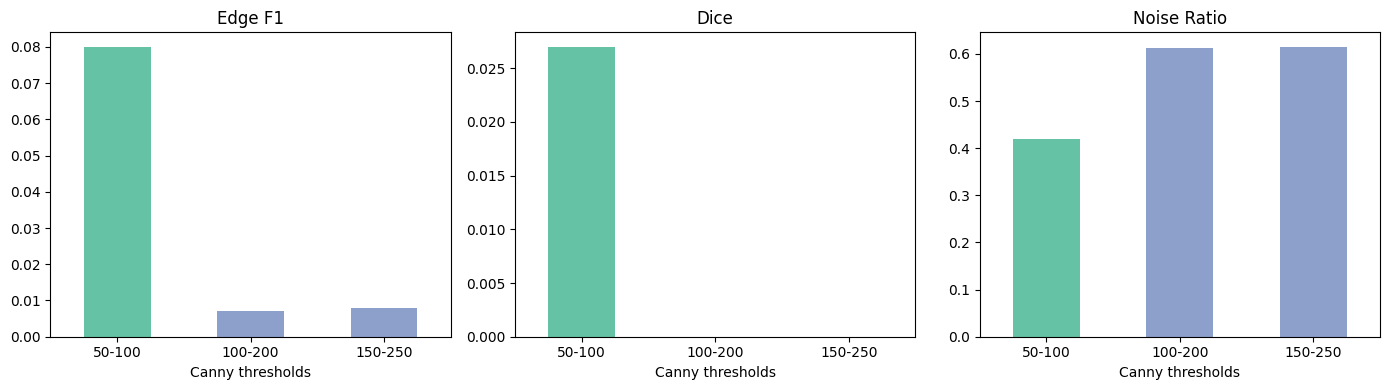

In [10]:
best_label = task4_summary["Score"].idxmax()
BEST_LO, BEST_HI = map(int, best_label.split("-"))
best_idx = [f"{lo}-{hi}" for lo, hi in THRESHOLDS].index(best_label)

print(f"Selected threshold: {best_label}")
for lbl, row in task4_summary.iterrows():
    print(f"{lbl}: edge pixels {row['Edge Pixels']:.0f}, edge F1 {row['Edge F1']:.3f}, Dice {row['Dice']:.3f}, noise ratio {row['Noise Ratio']:.3f}, score {row['Score']:.3f}")

task4.to_csv("table_threshold_selection.csv", index=False)
task4_summary.to_csv("table_threshold_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Edge F1", "Dice", "Noise Ratio"]):
    task4_summary[col].plot(kind="bar", ax=ax, color=["#8da0cb" if l != best_label else "#66c2a5" for l in task4_summary.index])
    ax.set_title(col)
    ax.set_xlabel("Canny thresholds")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("task4_threshold_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 5 — Detect the Lesion Boundary

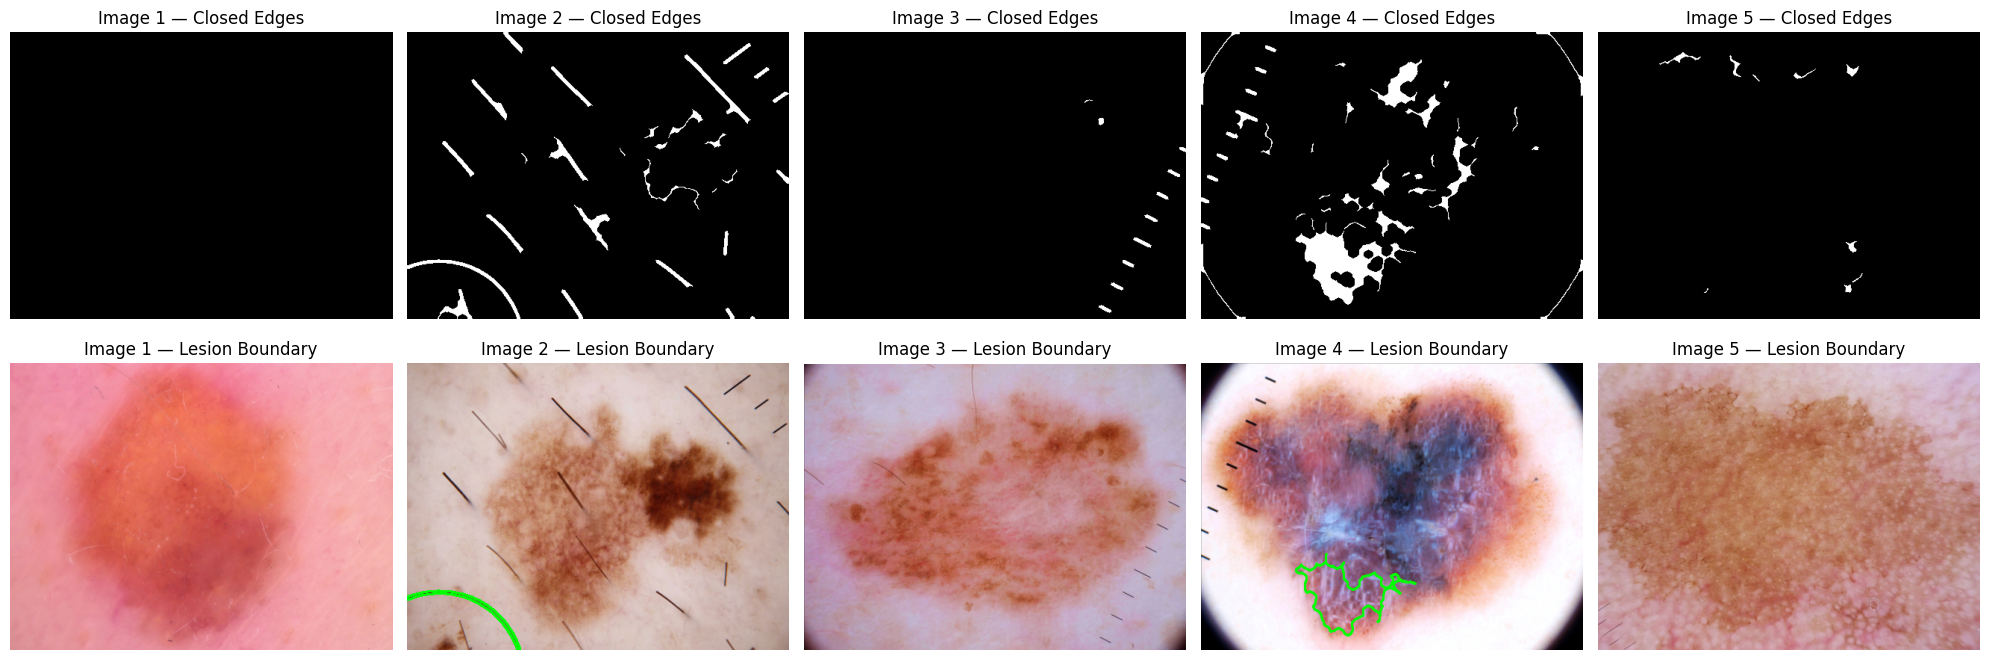

In [11]:
results = []
overlays, edge_maps, masks, contours = [], [], [], []
for r in range(len(originals)):
    e = cv2.Canny(gaussians[r], BEST_LO, BEST_HI)
    mask, cnt = extract_boundary(e)
    ov = originals[r].copy()
    if cnt is not None:
        cv2.drawContours(ov, [cnt], -1, (0, 255, 0), 2)
    edge_maps.append(e)
    masks.append(mask)
    contours.append(cnt)
    overlays.append(ov)

fig, axes = plt.subplots(2, len(originals), figsize=(4 * len(originals), 7))
for r in range(len(originals)):
    axes[0, r].imshow(close_edges(edge_maps[r]), cmap="gray")
    axes[0, r].set_title(f"{names[r]} — Closed Edges")
    axes[0, r].axis("off")
    axes[1, r].imshow(overlays[r])
    axes[1, r].set_title(f"{names[r]} — Lesion Boundary")
    axes[1, r].axis("off")
plt.tight_layout()
plt.savefig("task5_lesion_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6 — Calculate Lesion Area and Perimeter

In [12]:
for r in range(len(originals)):
    if contours[r] is None:
        area, per = 0, 0.0
    else:
        area = int(cv2.countNonZero(masks[r]))
        per = float(cv2.arcLength(contours[r], True))
    results.append({
        "Image": names[r],
        "Best Filter": "Gaussian",
        "Edge Method": f"Canny ({BEST_LO}-{BEST_HI})",
        "Area (pixels)": area,
        "Perimeter (pixels)": round(per, 2),
    })

results_df = pd.DataFrame(results)
results_df.to_csv("table_lesion_area_perimeter.csv", index=False)
results_df

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny (50-100),0,0.00
1,Image 2,Gaussian,Canny (50-100),893,396.33
2,Image 3,Gaussian,Canny (50-100),0,0.00
3,Image 4,Gaussian,Canny (50-100),6498,666.04
4,Image 5,Gaussian,Canny (50-100),0,0.00


## Required Visualization

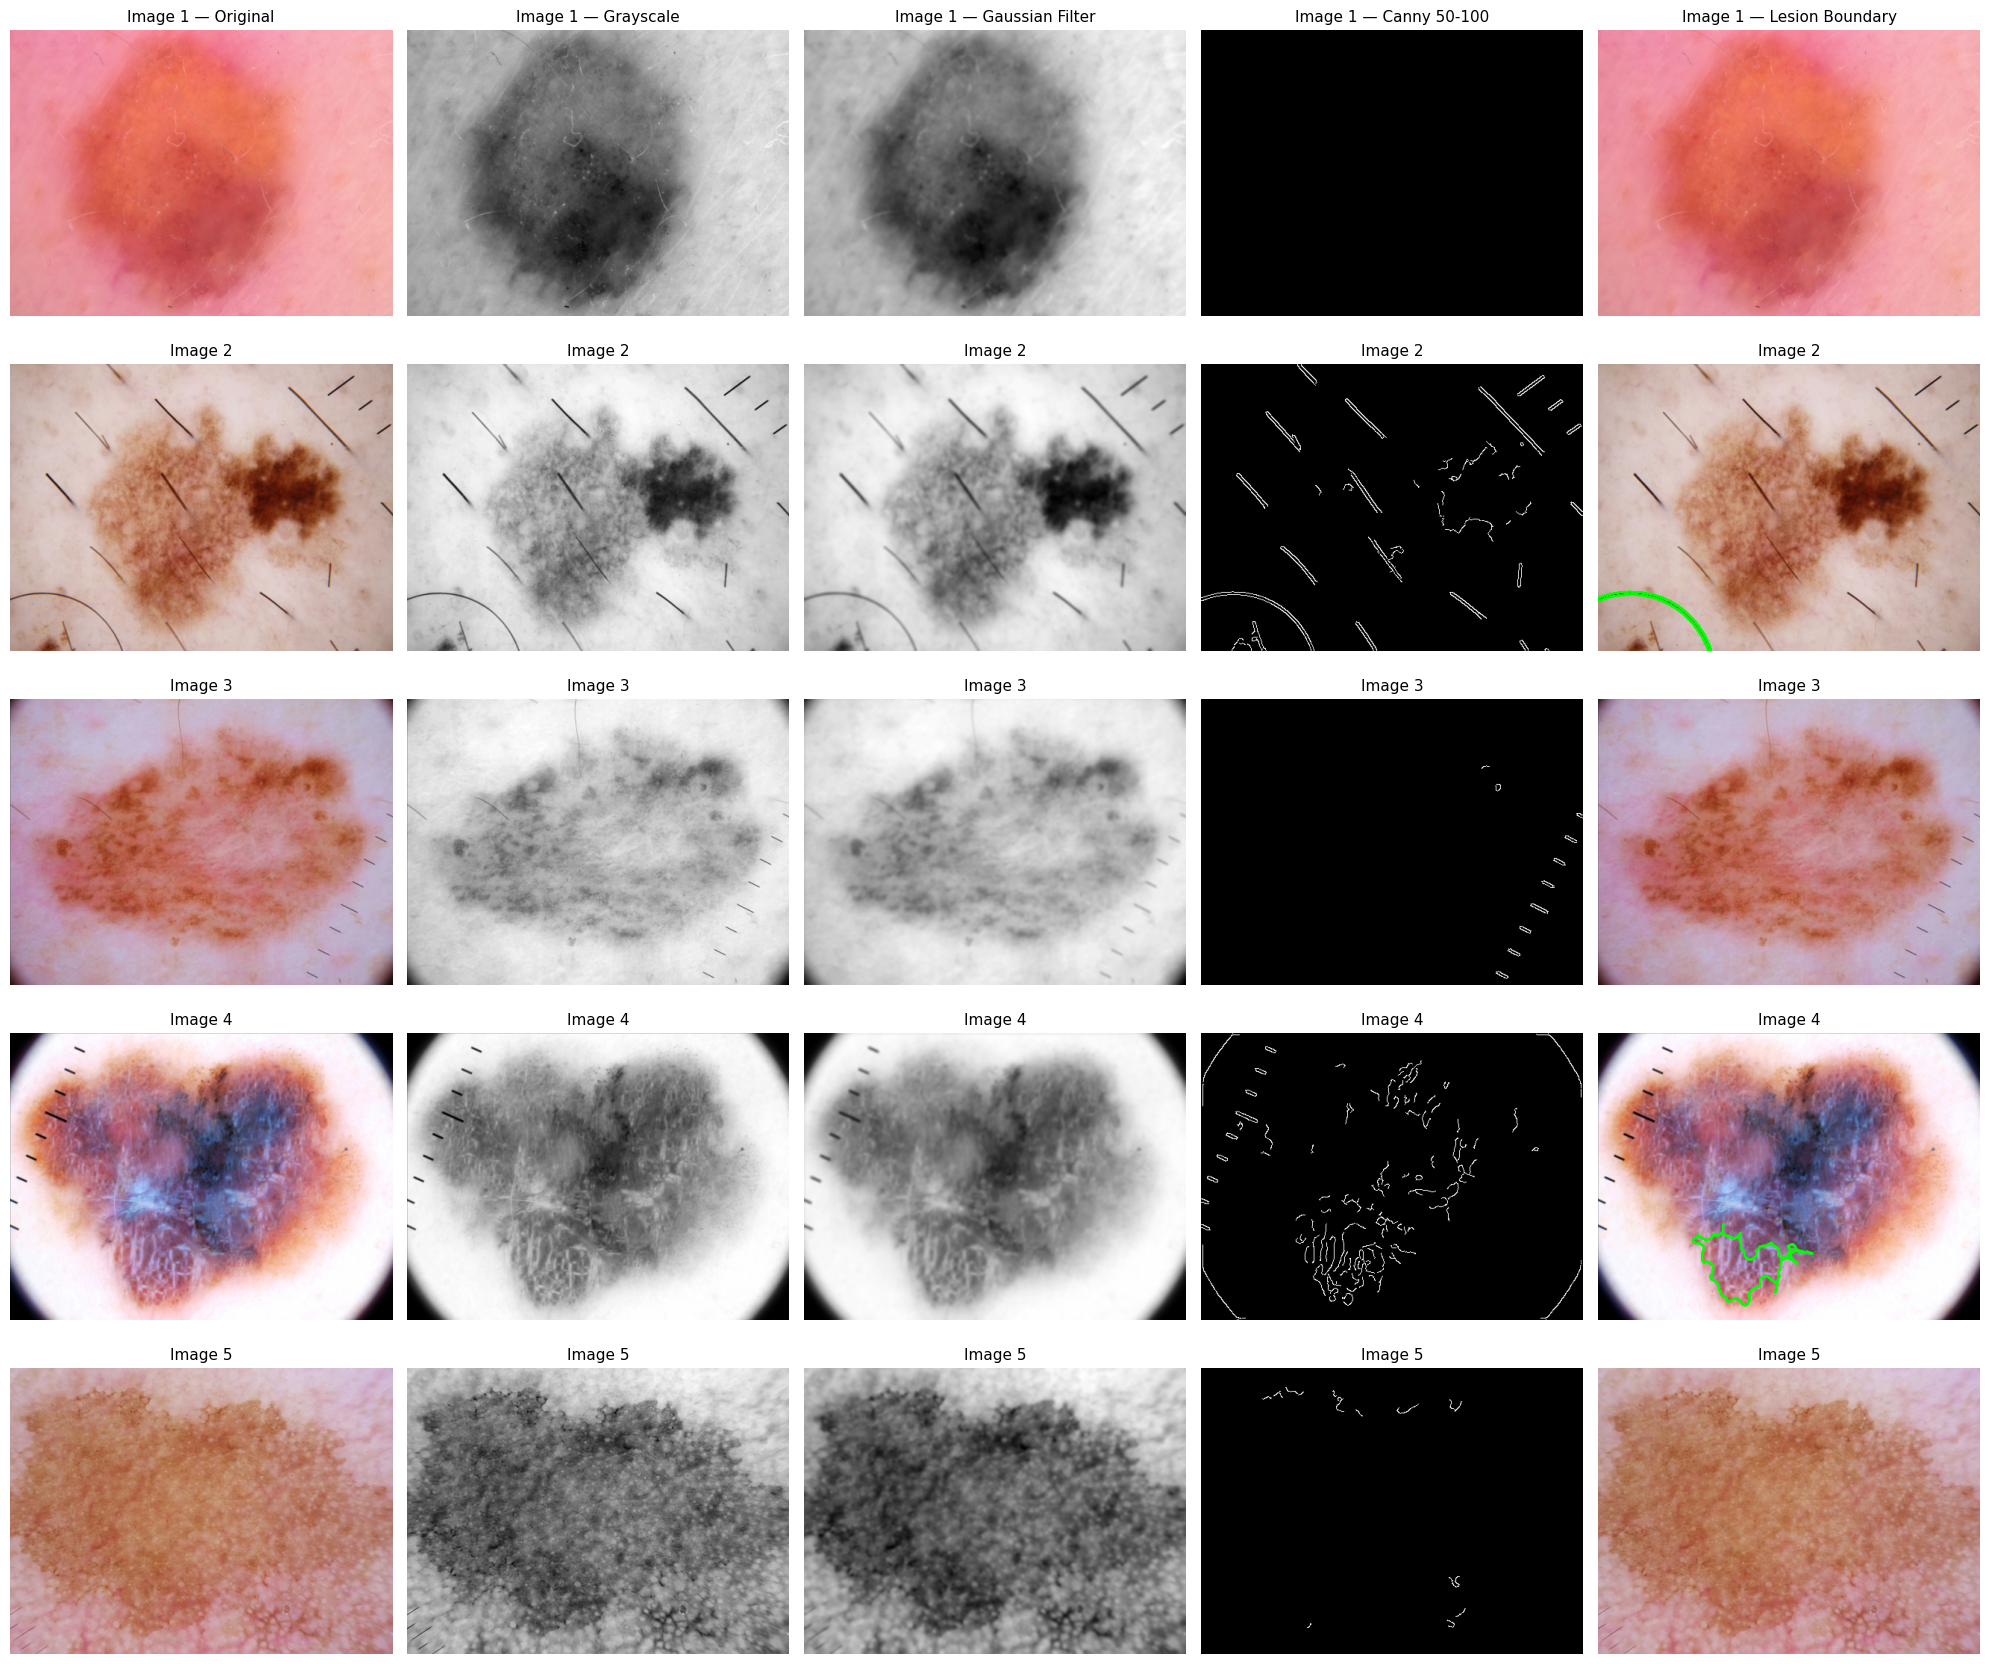

In [13]:
fig, axes = plt.subplots(len(originals), 5, figsize=(20, 3.4 * len(originals)))
titles = ["Original", "Grayscale", "Gaussian Filter", f"Canny {BEST_LO}-{BEST_HI}", "Lesion Boundary"]
for r in range(len(originals)):
    panels = [(originals[r], None), (grays[r], "gray"), (gaussians[r], "gray"), (edge_maps[r], "gray"), (overlays[r], None)]
    for c, (im, cm) in enumerate(panels):
        axes[r, c].imshow(im, cmap=cm)
        axes[r, c].axis("off")
        axes[r, c].set_title(f"{names[r]} — {titles[c]}" if r == 0 else names[r], fontsize=11)
plt.tight_layout()
plt.savefig("final_pipeline.png", dpi=130, bbox_inches="tight")
plt.show()

## Final Comparison

In [14]:
def sobel_binary(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.convertScaleAbs(np.sqrt(gx ** 2 + gy ** 2))
    _, b = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return b


def canny_best(gray):
    return cv2.Canny(gray, BEST_LO, BEST_HI)


filters = {
    "Original": lambda g: g,
    "Average": lambda g: cv2.blur(g, (7, 7)),
    "Gaussian": lambda g: cv2.GaussianBlur(g, (7, 7), 1.5),
    "Median": lambda g: cv2.medianBlur(g, 7),
}
detectors = {"Sobel": sobel_binary, "Canny": canny_best}

comparison_maps = {}
rows = []
for f_name, f in filters.items():
    for d_name, d in detectors.items():
        nz, eq, bd = [], [], []
        for r in range(len(originals)):
            e = d(f(grays[r]))
            mask, _ = extract_boundary(e)
            nz.append(1 - noise_ratio(e))
            eq.append(edge_f1(e, refs[r]))
            bd.append(dice(mask, refs[r]))
            if r == 0:
                comparison_maps[f"{f_name} + {d_name}"] = e
        rows.append({
            "Method": f"{f_name} + {d_name}",
            "Noise Handling": np.mean(nz),
            "Edge Quality": np.mean(eq),
            "Boundary Detection": np.mean(bd),
        })

comp = pd.DataFrame(rows)
comp["Overall Performance"] = comp[["Noise Handling", "Edge Quality", "Boundary Detection"]].mean(axis=1)
comp = comp.round(3)
comp

,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,0.784,0.155,0.730,0.556
1,Original + Canny,0.609,0.160,0.452,0.407
2,Average + Sobel,0.946,0.259,0.658,0.621
3,Average + Canny,0.299,0.032,0.000,0.110
4,Gaussian + Sobel,0.914,0.212,0.644,0.590
5,Gaussian + Canny,0.582,0.080,0.027,0.229
6,Median + Sobel,0.885,0.272,0.634,0.597
7,Median + Canny,0.600,0.142,0.041,0.261


In [15]:
def grade(series):
    return series.apply(lambda v: "High" if v >= 0.8 else ("Medium" if v >= 0.5 else "Low"))


final_table = comp.copy()
for col in ["Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"]:
    final_table[col] = grade(comp[col]) + " (" + comp[col].map("{:.3f}".format) + ")"

final_table.to_csv("table_final_comparison.csv", index=False)
comp.to_csv("table_final_comparison_scores.csv", index=False)
final_table

,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Medium (0.784),Low (0.155),Medium (0.730),Medium (0.556)
1,Original + Canny,Medium (0.609),Low (0.160),Low (0.452),Low (0.407)
2,Average + Sobel,High (0.946),Low (0.259),Medium (0.658),Medium (0.621)
3,Average + Canny,Low (0.299),Low (0.032),Low (0.000),Low (0.110)
4,Gaussian + Sobel,High (0.914),Low (0.212),Medium (0.644),Medium (0.590)
5,Gaussian + Canny,Medium (0.582),Low (0.080),Low (0.027),Low (0.229)
6,Median + Sobel,High (0.885),Low (0.272),Medium (0.634),Medium (0.597)
7,Median + Canny,Medium (0.600),Low (0.142),Low (0.041),Low (0.261)


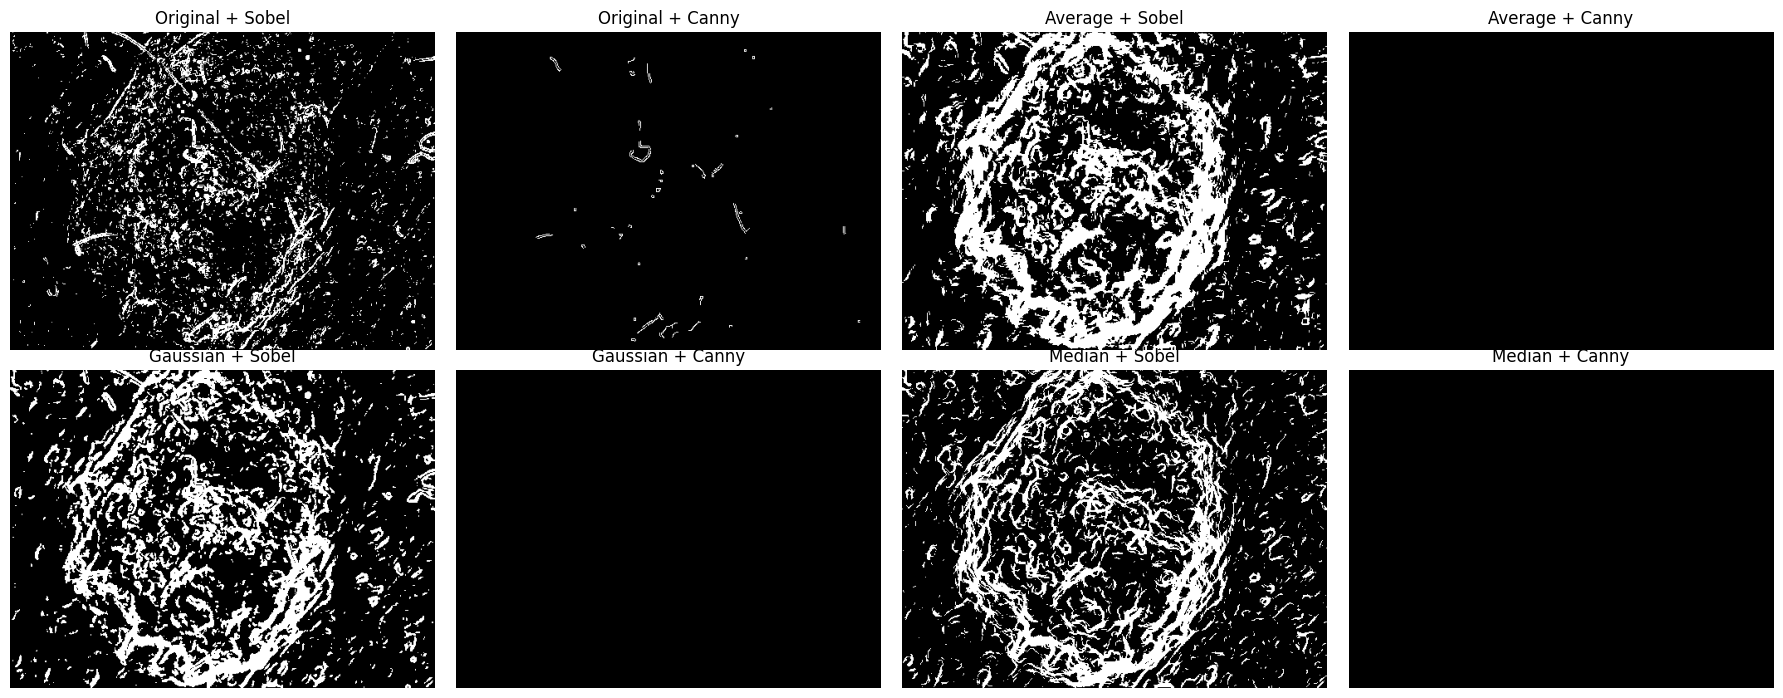

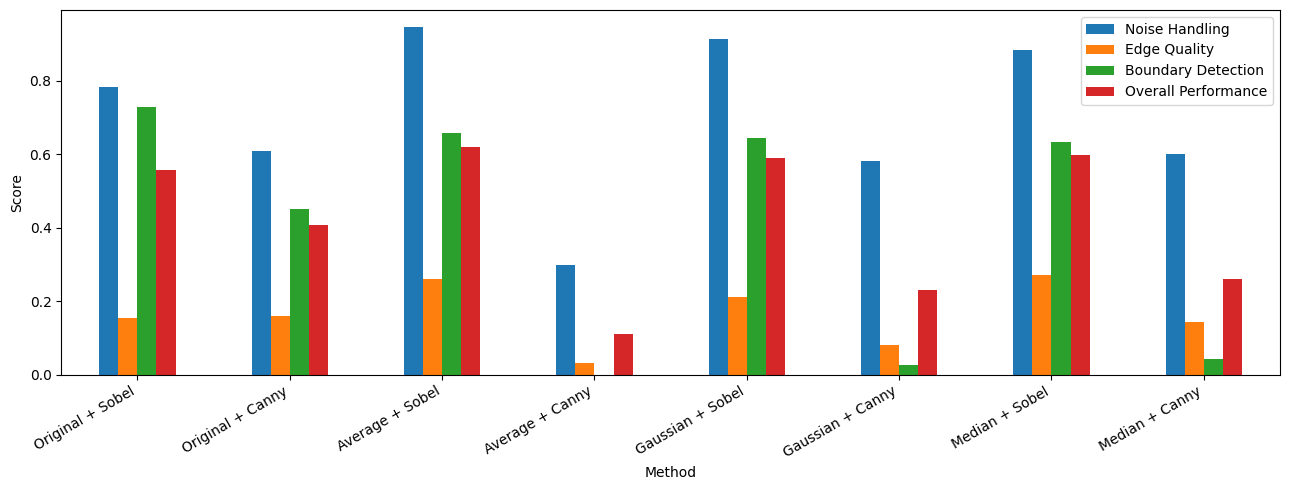

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, (label, e) in zip(axes.ravel(), comparison_maps.items()):
    ax.imshow(e, cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.savefig("final_comparison_edges.png", dpi=130, bbox_inches="tight")
plt.show()

comp.set_index("Method")[["Noise Handling", "Edge Quality", "Boundary Detection", "Overall Performance"]].plot(kind="bar", figsize=(13, 5))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("final_comparison_scores.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
for lbl, row in task4_summary.iterrows():
    print(f"   {lbl}: {row['Edge Pixels']:.0f} edge pixels on average, edge F1 {row['Edge F1']:.3f}, Dice {row['Dice']:.3f}, noise ratio {row['Noise Ratio']:.3f}")

print()
print(f"   {best_label}, with the highest combined score of {task4_summary.loc[best_label, 'Score']:.3f}")

print()

for r in range(len(originals)):
    d = dice(masks[r], refs[r])
    h, w = masks[r].shape
    ys, xs = np.nonzero(masks[r])
    touches = bool(len(ys)) and (ys.min() == 0 or xs.min() == 0 or ys.max() == h - 1 or xs.max() == w - 1)
    ratio = (masks[r] > 0).sum() / max((refs[r] > 0).sum(), 1)
    print(f"   {names[r]}: Dice {d:.3f}, detected/reference area {ratio:.2f}, touches border: {touches}, boundary found: {contours[r] is not None}")

   50-100: 1561 edge pixels on average, edge F1 0.080, Dice 0.027, noise ratio 0.419
   100-200: 459 edge pixels on average, edge F1 0.007, Dice 0.000, noise ratio 0.612
   150-250: 314 edge pixels on average, edge F1 0.008, Dice 0.000, noise ratio 0.615

   50-100, with the highest combined score of 0.229

   Image 1: Dice 0.000, detected/reference area 0.00, touches border: False, boundary found: False
   Image 2: Dice 0.000, detected/reference area 0.02, touches border: True, boundary found: True
   Image 3: Dice 0.000, detected/reference area 0.00, touches border: False, boundary found: False
   Image 4: Dice 0.133, detected/reference area 0.07, touches border: False, boundary found: True
   Image 5: Dice 0.000, detected/reference area 0.00, touches border: False, boundary found: False
